# 딥러닝응용I(추천시스템) · W02B
**동덕여자대학교 데이터사이언스전공 · 유원상 교수 · 2026년 2학기**

## 기본적인 추천 방법 (2) · 2026-09-10 10:30
집단 평균을 수계산하고, 실제 MovieLens에서 fit→predict→평가를 추적한 뒤
내용 기반 추천과 네 방법의 동일 조건 비교, 웹 앱 연결을 수행한다.
문제의 None은 직접 작성할 부분이다. 미완성 문제는 안내 후 다음 독립 실습으로
넘어갈 수 있다. 예상값과 실제값을 구분하여 기록한다. 원본 평점이나 사용자 속성 표를
공유 출력하지 않는다. 원자료는 자동 준비되며 업로드·API 키가 필요 없다.

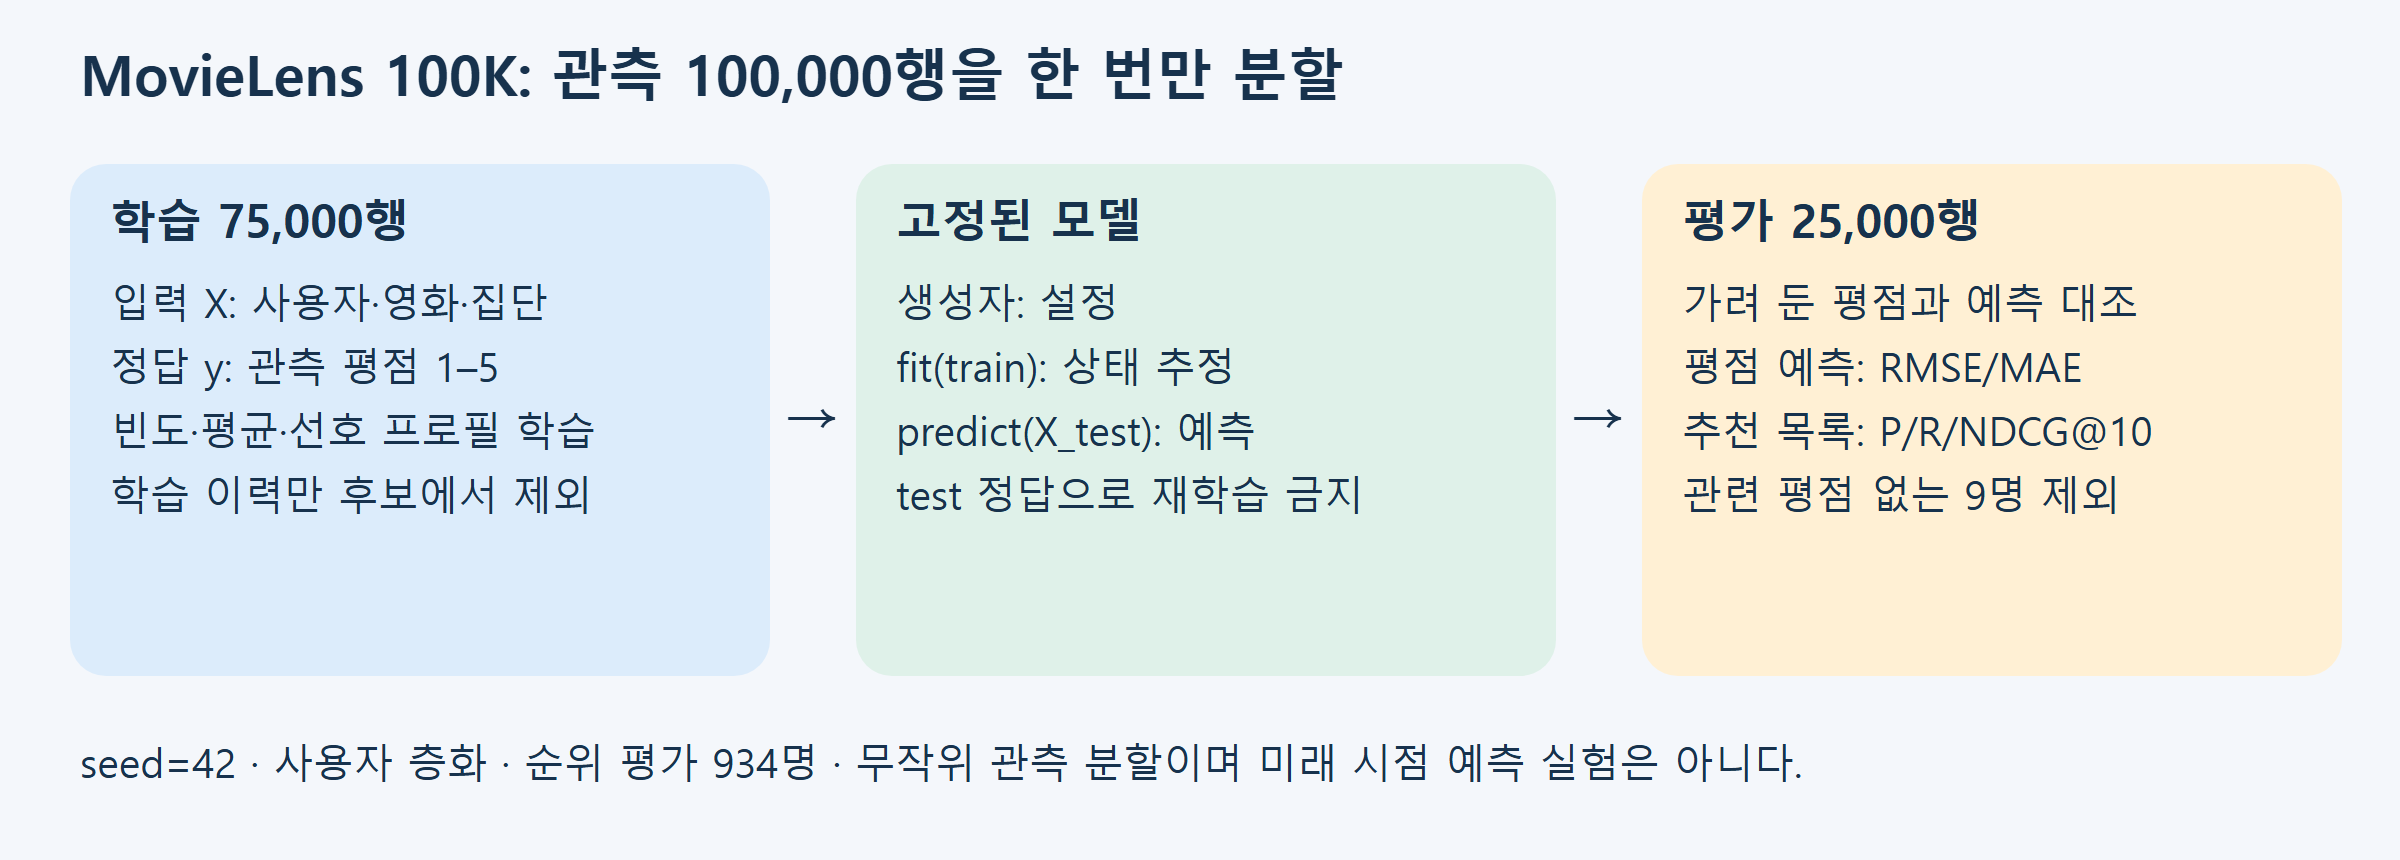


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w02b/course/notion/assets/w02b/holdout-flow.svg)


## 1. 실행할 수업 버전 준비
Colab에서는 검토한 공개 태그의 패키지를 현재 Python에 설치한다.
`sys.executable`은 현재 커널의 Python, `subprocess.run(..., check=True)`는
설치 명령 실행과 실패 시 중단을 뜻한다. `[apps]`는 Gradio 선택 의존성을 포함한다.
태그가 아직 공개되지 않은 검토 단계에는 Colab 설치가 불가능하다. 로컬 검증에서는
현재 저작 패키지를 사용하며, 이를 실제 Colab UI 확인으로 기록하지 않는다.
`os.getenv`는 선택 환경 설정, `Path`는 운영체제에 맞는 폴더 경로를 다룬다.


## 가져다 쓰는 코드: 호출 전에 읽기

[Complete API reference](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/API.md)

### [comparison_cards · definition](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/comparison_app.py#L28)

comparison_table 결과에서 방법별 상위 3개를 반응형 HTML로 표시한다.

table: method/rank/title/genres/score/basis 열이 있는 DataFrame.
반환값: gradio.HTML에 넣을 문자열. 원본 table과 점수는 변경하지 않는다.
제목과 근거는 HTML 이스케이프하여 텍스트로 표시한다. 작은 화면에서는
카드가 한 열로 배치되며 전체 순위는 별도 표에서 확인한다.

### [build_comparison_app · definition](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/comparison_app.py#L51)

학습된 model을 사용하는 gradio.Blocks 객체를 만들고 반환한다.

model: fit이 끝난 FourMethodRecommender. 사용자 선택은 학습 사용자 ID,
목록 길이는1–20이다. 반환 앱의 launch(share=True)는 호출자가 Colab에서
실행한다. 이 함수 자체는 네트워크 서버를 띄우거나 데이터를 다운로드하지
않는다. [apps] 선택 의존성인 Gradio가 없으면 ImportError가 발생한다.
화면 입력은 callback에서 정수로 변환하여 comparison_table에 전달한다.


In [ ]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
COURSE_VERSION = "2026-fall-w02b"
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        f"luna-recommender-course[apps] @ git+https://github.com/lunalab-ai/recommender.git@{COURSE_VERSION}"], check=True)
else:
    print("로컬 저작 패키지 실행; Colab UI 검증과 구분합니다.")


## 2. 함수·자료형을 이해하고 실제 데이터를 준비한다
`numpy`는 배열 연산, `pandas`는 행·열 표, `matplotlib.pyplot`은 그래프,
`IPython.display.display`는 notebook의 표 출력 도구다.

`prepare_movielens(cache_dir, local_dir=None, mode="auto", timeout=20)`:
캐시 폴더를 재사용하거나 다운로드하고 `.data/.mode/.description`을 가진 객체를 반환한다.
`.data`의 `users`는 사용자 943행, `movies`는 영화 1682행, `ratings`는 관측 100000행이다.
API 기본 auto와 달리 여기서는 **mode="real"**을 지정한다. 다운로드 실패를 합성 결과로 숨기지 않는다.
`local_dir`는 교수자 로컬 검증용 선택 경로이고 학생은 입력하지 않아도 된다.
[prepare_movielens 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/datasets.py#L62) · [PreparedMovieLens 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/datasets.py#L16) · [MovieLens100K 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/data.py#L58)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from luna_recsys.datasets import prepare_movielens

cache = Path("/content/recommender-data") if IN_COLAB else Path.home()/".cache/luna-recsys"
prepared = prepare_movielens(cache, local_dir=os.getenv("RECOMMENDER_DATA_DIR") or None, mode="real")
data = prepared.data
users, movies, ratings = data.users, data.movies, data.ratings
print(prepared.description)
display(pd.DataFrame({"table":["users","movies","ratings"],"rows":[len(users),len(movies),len(ratings)]}))
assert (len(users),len(movies),len(ratings)) == (943,1682,100000)


## 3. 문제 1 · 같은 묶음의 평균을 수계산하기
집단×영화 묶음 $D_{gi}$의 관측 수가 $n_{gi}>0$이면 학습되는 모수는
$$\widehat\theta_{gi}=\frac{1}{n_{gi}}\sum_{(u,i,r_{ui})\in D_{gi}}r_{ui}.$$
이는 $\sum_{(u,i,r_{ui})\in D_{gi}}(r_{ui}-\theta)^2$를 최소화하는 값이다.
아래 표는 독자적으로 만든 작은 자료다. 동쪽×A 평균, 전체 영화 A 평균,
전체 평균을 계산하고 `theta_east_a`에 첫 값을 넣는다. 최소 집단 표본 수가 2일 때
동쪽×B의 예측값과 **사용한 기준**도 설명하라. 목표는 분모와 대체 규칙을 구별하는 것이다.
힌트: 집단 인원수가 아니라 해당 영화 관측 수를 센다.


In [ ]:
toy = pd.DataFrame({"user_id":[1,2,1,3,4], "group":["east","east","east","west","west"],
                    "movie_id":[1,1,2,1,1], "rating":[3,5,2,1,5]})
display(toy)
theta_east_a = None
if theta_east_a is None:
    print("문제 1: 수계산한 값을 입력하세요.")
else:
    assert np.isclose(theta_east_a, toy.loc[(toy.group=="east") & (toy.movie_id==1),"rating"].mean())


## 4. 관측 행을 한 번 분할한다
`split_ratings(ratings, test_size=0.25, seed=42)`는 원본을 바꾸지 않고
`RatingSplit(train, test, method)`를 반환한다. 가능한 경우 사용자별 층화이며
같은 사용자는 양쪽에 있을 수 있지만 같은 관측 쌍은 겹치지 않는다.
`test_size`는 평가 비율, `seed`는 같은 환경에서 분할을 재현하는 난수 설정이다.
timestamp 순서의 미래 예측 실험과는 다르다.
[split_ratings 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/evaluation.py#L28) · [RatingSplit 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/evaluation.py#L17)


In [ ]:
from luna_recsys.evaluation import split_ratings
split = split_ratings(ratings, test_size=0.25, seed=42)
train, test = split.train, split.test
print(len(train), len(test), split.method)
train_pairs = set(zip(train.user_id, train.movie_id))
test_pairs = set(zip(test.user_id, test.movie_id))
assert len(train)==75000 and len(test)==25000 and train_pairs.isdisjoint(test_pairs)


## 5. 클래스 생성과 학습 후 상태를 추적한다
`MeanRatingPredictor(mode="movie", group_col="sex", min_group_ratings=1)`는 클래스다.
global/movie/group 중 기준, 사용자 속성 열, 집단×영화의 최소 관측 수를 설정한다.
`fit(train, users)`는 user_id/movie_id/rating 표에서 평균을 추정하고 자기 자신을 반환한다.
group 모드만 사용자 속성 표가 필요하다. 학습 후 `global_mean_`(숫자),
`movie_means_`(영화 ID별 Series), `group_means_`(집단·영화 다중 인덱스)가 생긴다.
`predict_details(pairs)`는 user_id/movie_id 표를 받고 같은 순서로 prediction/level을 반환한다.
`predict(pairs)`는 그중 예측 Series만 반환한다. test의 rating은 필요 없다.
[MeanRatingPredictor 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/rating_models.py#L29) · [MeanRatingPredictor.fit 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/rating_models.py#L77) · [MeanRatingPredictor.predict_details 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/rating_models.py#L115) · [MeanRatingPredictor.predict 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/rating_models.py#L147)


In [ ]:
from luna_recsys.rating_models import MeanRatingPredictor
model = MeanRatingPredictor("group", group_col="sex", min_group_ratings=1)
assert not hasattr(model, "global_mean_")
returned = model.fit(train, users)
assert returned is model
print("전체 평균 모수:", model.global_mean_)
print("영화 평균 모수 수:", len(model.movie_means_))
print("집단×영화 모수 수:", len(model.group_means_))
# 특정 영화의 집계는 원본 사용자별 평점 대신 학습 통계를 보여준다.
movie_example = 50
print("영화 ID 50의 학습 평점 수와 평균:", int(train.movie_id.eq(movie_example).sum()), model.movie_means_.loc[movie_example])
pairs = test[["user_id","movie_id"]]
details = model.predict_details(pairs)
display(details.level.value_counts().rename("예측에 사용한 행 수"))


### 문제 2 · fit이 학습한 값과 predict 입력 설명
영화 ID50의 평균을 `train`에서 직접 계산하여 저장된 값과 대조하라.
이어 “predict에 실제 평점 열을 주지 않았는데 어떻게 평가할 수 있는가?”에 답하라.
힌트: 모델과 평가자가 각각 보는 정보를 구분한다.


In [ ]:
my_movie_mean = None
my_evaluation_explanation = "직접 작성"
if my_movie_mean is None:
    print("문제 2: movie_id로 학습 행을 선택하고 rating 평균을 계산하세요.")
else:
    assert np.isclose(my_movie_mean, model.movie_means_.loc[movie_example])


## 6. 정답을 열어 오차를 계산한다
`to_numpy()`는 같은 행 순서의 숫자 배열을 꺼낸다. 오차는 실제−예측,
MAE는 절댓값 평균, RMSE는 제곱 평균의 제곱근이다. 아래 값은 1–5점 척도의 예측 평점으로 계산한다.

$$\operatorname{MAE}=\frac1n\sum_{k=1}^n|y_k-\widehat y_k|,\qquad\operatorname{RMSE}=\sqrt{\frac1n\sum_{k=1}^n(y_k-\widehat y_k)^2}.$$


In [ ]:
truth = test.rating.to_numpy()
predictions = details.prediction.to_numpy()
errors = truth-predictions
print("MAE:", np.abs(errors).mean(), "RMSE:", np.sqrt(np.mean(errors**2)))
small_errors = np.array([5,2,4])-np.array([4,3,4])
assert np.isclose(np.abs(small_errors).mean(),2/3)
assert np.isclose(np.sqrt(np.mean(small_errors**2)),np.sqrt(2/3))


`evaluate_means(split, users, group_col="sex", min_group_ratings=1)`는 같은 분할에서
전체/영화/집단 평균을 각각 fit하고 RMSE 및 level별 사용 건수의 표를 반환한다.
입력은 RatingSplit과 사용자 표이며 test로 모델을 조정하지 않는다.
[evaluate_means 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/evaluation.py#L60)


In [ ]:
from luna_recsys.evaluation import evaluate_means
rating_results = evaluate_means(split,users,group_col="sex",min_group_ratings=1)
display(rating_results)


### 문제 3 · 누수 코드 고치기
`MeanRatingPredictor().fit(ratings)`로 전체 자료를 학습하고 test에서 평가하려 한다.
잘못된 입력을 고친 뒤, test의 rating만 바꾸면 학습된 예측이 바뀌어야 하는지 설명하라.
아래 None에 올바른 학습 표를 넣는다. 후속 실습은 이 답안에 의존하지 않는다.


In [ ]:
chosen_training_data = None
if chosen_training_data is None:
    print("문제 3: 전체 자료와 학습 부분의 차이를 확인하세요.")
else:
    corrected_model = MeanRatingPredictor().fit(chosen_training_data)
    print("모형 준비. 학습에 사용한 행 집합의 근거를 적으세요.")


## 7. 교재 2.5의 TF–IDF를 작은 문장으로 확인한다
교재는 별도 영화 줄거리 데이터, 이 셀은 독자적인 세 문장이다.
`TfidfVectorizer()`의 `fit_transform(documents)`는 문자열 목록에서 어휘·IDF를 추정하여
문서 수×어휘 수 희소행렬을 반환한다. 기본값은 smooth_idf=True, norm="l2"다.
`get_feature_names_out()`은 열 이름이다. 행 벡터가 L2 정규화되어 내적이 코사인이 된다.
이 fit은 평점 정답을 쓰지 않으므로 앞의 평균 회귀와 구별한다.
[공식 인자·속성 설명](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
documents = ["space robot adventure","space adventure","family comedy"]
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(documents)
display(pd.DataFrame(features.toarray(),columns=vectorizer.get_feature_names_out()))
similarity_to_first = (features @ features[0].T).toarray().ravel()
print("첫 문서와의 코사인:",similarity_to_first)
assert np.isclose(similarity_to_first[0],1) and similarity_to_first[1]>similarity_to_first[2]


### 문제 4 · 자기 자신과 데이터 종류 구별
첫 문서가 왜 유사도1인지, 추천에서 어떻게 제외할지 설명하라.
MovieLens 100K에 같은 줄거리 열이 없는데도 이 표의 결과를 네 방법 성능표에
섞어도 되는가? 단어 공유 여부와 평가 대상의 동일성을 근거로 답하라.


## 8. 장르 벡터와 사용자 프로필
`FourMethodRecommender(group_col="sex", min_group_ratings=1, like_threshold=4)`는
네 기준을 공통 카탈로그에 맞추는 클래스다. `fit(train, users, movies)`는 평점 수·평균,
train에서 4점 이상 준 영화의 정규화 장르 평균을 저장한다. 장르 메타데이터는 예측 시
알려져 있다고 가정하며 unknown을 제외한18차원을 쓴다. `genre_vectors_`는 영화×18,
`profiles_`는 사용자 ID→18차원 단위벡터, `seen_`은 학습 영화 집합이다.
`recommend(user_id, method, k=10)`은 train에서 본 영화만 제외한 최대k행의
movie_id/score/basis/title/genres 표를 반환한다. 동점은 movie_id 오름차순이다.
내용 프로필이 없으면 영화 평균 목록으로 대체한다. 장르 없는 후보의 코사인은0이다.
[FourMethodRecommender 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/ranking.py#L18) · [FourMethodRecommender.fit 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/ranking.py#L59) · [FourMethodRecommender.recommend 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/ranking.py#L143)


In [ ]:
from luna_recsys.ranking import FourMethodRecommender
ranker = FourMethodRecommender().fit(train,users,movies)
print("장르 행렬:",ranker.genre_vectors_.shape,"유효 사용자 프로필:",len(ranker.profiles_))
display(ranker.recommend(1,"content",k=5))


### 문제 5 · 코사인 수계산
사용자가 액션 영화만 좋아하여 프로필이 (1,0)이고, 후보가 액션·코미디 (1,1)이다.
양쪽을 정규화해 코사인을 구하라. 왜 두 벡터의 정규화 전 내적1을 그대로 쓰면
안 되는가? 힌트: 장르 수 때문에 벡터 길이가 달라진다.


In [ ]:
student_cosine = None
if student_cosine is None:
    print("문제 5: 내적을 두 벡터 길이의 곱으로 나누세요.")
else:
    assert np.isclose(student_cosine,1/np.sqrt(2))


## 9. 순위 평가를 손으로 확인한다
`ranking_metrics(recommended, relevant, k=10)`는 순서가 있는 영화 ID 목록과
관련 ID 집합에서 precision/recall/ndcg/hits 사전을 반환한다. 중복 추천과 빈
관련 집합은 오류다. Precision 분모는k, Recall 분모는 관련 집합 크기다.
NDCG는 log2(rank+1) 할인과 이상적 이진 순위로 계산한다.
[ranking_metrics 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/ranking.py#L163)


In [ ]:
from luna_recsys.ranking import ranking_metrics
small_metrics = ranking_metrics([10,20,30],{10,30},k=3)
print(small_metrics)


### 문제 6 · 같은 적중 수라도 앞에 두면?
위 목록을 [10,30,20]으로 바꾸면 Precision/Recall/NDCG는 각각 어떻게 되는가?
실행 전 예측을 적고 두 결과를 비교하라.


In [ ]:
metric_prediction = "직접 예측을 적으세요."
better_order = ranking_metrics([10,30,20],{10,30},k=3)
display(pd.DataFrame([small_metrics,better_order],index=["1·3위 적중","1·2위 적중"]))


## 10. 실제 동일 데이터의 네 방법 전체 평가
`evaluate_rankings(model, test, k=10, relevance_threshold=4)`는 학습된 모델을
고정하고 요약표·사용자별 결과표·조건 사전을 반환한다. 모든 방법에 같은 카탈로그,
같은 train 이력 제외, 같은 평가 사용자와 K를 적용한다. 관련 test 영화 없는 사용자는
공통 제외된다. 요약은 사용자별 단순평균이다. 사용자별 표는 공개 출력/저장하지 않는다.
catalog_coverage는 전체1,682편 중 추천된 고유 영화의 비율이며 개인별 다양성과 다르다.
fallback_fraction은 상위 목록에서 대체 기준을 쓴 항목 비율이다.
[evaluate_rankings 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/ranking.py#L186)


In [ ]:
from luna_recsys.ranking import evaluate_rankings
ranking_results, private_per_user, evaluation_info = evaluate_rankings(ranker,test,k=10)
print(evaluation_info)
display(ranking_results)
fig,axes = plt.subplots(1,3,figsize=(12,3.5),layout="constrained")
for ax,metric in zip(axes,["precision","recall","ndcg"]):
    bars=ax.bar(ranking_results.method,ranking_results[metric])
    ax.bar_label(bars,fmt="%.4f",padding=3,fontsize=8)
    ax.set_title(metric+"@10"); ax.set_ylim(0,max(ranking_results[metric])*1.25)
plt.show()


### 문제 7 · 지표와 추천 목록을 함께 설명한다
실험 전에 정한 익명 사례 A/B의 네 목록을 비교한다. count와 mean의 개인별 목록 차이가
모두 선호 학습 때문인지, 높은 평균이 적은 표본에서 나온 것인지, 내용 기반 목록이
특정 장르를 반복하는지 살핀다. content의 커버리지가 높으면 만족도도 높은가?
MovieLens에서 미관측인 영화가 싫어하는 영화라고 단정할 수 있는가?


In [ ]:
from luna_recsys.ranking import METHODS
case_users = {"A":1,"B":13}  # 평가 결과를 보고 고른 사례가 아니다.
for case_name,user_id in case_users.items():
    print("익명 사례",case_name)
    for method in METHODS:
        print(method)
        listing = ranker.recommend(user_id,method,k=5)
        listing["train_count"] = listing.movie_id.map(ranker.counts_)
        display(listing)
my_comparison = "관측값을 인용하여 장점·한계와 평가의 한계를 적으세요."


## 11. 학습된 모델을 웹 앱으로 연결한다
`comparison_table(model, user_id, k=10)`은 네 방법의 최대4k행을 합친 DataFrame을
반환한다. method/rank/movie_id/title/genres/score/basis 열을 가진다.
`build_comparison_app(model)`은 Gradio Blocks를 반환하며 모델을 재학습하지 않는다.
`launch`는 실제 서버를 띄우고 `close`는 종료한다. 자동 검증에서는 callback과 앱 구성을
확인하며 Colab일 때만 공유 서버를 실행한다. HTTP/브라우저 검증과 callback 검증을 구분한다.
[comparison_table 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/comparison_app.py#L8) · [build_comparison_app 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/src/luna_recsys/comparison_app.py#L51)


In [ ]:
from luna_recsys.comparison_app import comparison_table,build_comparison_app
display(comparison_table(ranker,1,k=3))
app = build_comparison_app(ranker)
if IN_COLAB:
    app.launch(share=True,prevent_thread_lock=True)
else:
    print("앱 구성과 callback을 로컬 검증합니다.")


### 문제 8 · callback을 직접 수정해 연결하기
아래 함수에서 int 변환한 사용자 ID와 추천 수를 comparison_table에 전달하라.
완성한 callback을 Gradio의 두 입력과 출력 표에 연결하고 추천 수3일 때 최대12행인지
확인한다. 숫자의 단위가 다른 방법들을 하나의 점수로 재정렬하지 않는다.
미완성일 때 빈 표 안내만 반환하며 뒤의 검증은 완성된 공통 API를 별도로 사용한다.


In [ ]:
def student_callback(user_value,k_value):
    # TODO: comparison_table에 ranker와 int 변환한 두 값을 전달하세요.
    return None

student_table = student_callback(1,3)
if student_table is None:
    print("문제 8: callback을 완성한 뒤 버튼에 연결하세요.")
else:
    assert len(student_table)<=12 and student_table.method.nunique()==4
    display(student_table)


## 12. 실행 검증과 기록
다음 검사는 실제 데이터 크기·공통 분할·학습 통계·순위·callback의 기본 기능을
확인한다. 문제 풀이 완성을 대신하지 않는다. 실험 설정과 결과, 해석의 한계를
자신의 사본에 저장한다. 데이터 원본과 사용자별 평가 결과는 공유하지 않는다.


In [ ]:
assert prepared.mode in {"movielens","local"}
assert train_pairs.isdisjoint(test_pairs)
assert np.isclose(model.global_mean_,train.rating.mean())
assert details.prediction.between(1,5).all()
assert ranking_results[["precision","recall","ndcg","catalog_coverage"]].ge(0).all().all()
assert ranking_results[["precision","recall","ndcg","catalog_coverage"]].le(1).all().all()
assert ranking_results.users.nunique()==1
assert len(comparison_table(ranker,1,k=2))==8
assert ranker.genre_vectors_.shape==(1682,18)
for method in METHODS:
    assert set(ranker.recommend(1,method).movie_id).isdisjoint(ranker.seen_[1])
print("실제 데이터·학습/평가 분리·추천·callback 검사 통과")


## 점검 퀴즈

1. 집단×영화 평균의 분모는 집단 전체 인원수인가, 어떤 관측 수인가?
2. 경사하강법 없이 평균을 계산하는 것도 지도학습이라고 할 수 있는 이유는 무엇인가?
3. MeanRatingPredictor 객체를 만든 직후와 fit 직후의 차이는 무엇인가?
4. predict에 test의 실제 평점이 필요하지 않은 이유는 무엇인가?
5. MovieLens 100K에서 교재의 줄거리 대신 장르를 사용한 이유는 무엇인가?
6. 내용 프로필을 test에서 좋아한 영화까지 포함하여 만들면 어떤 문제가 생기는가?
7. 평점 수와 코사인 점수를 RMSE에 바로 넣지 않고 순위 지표로 비교한 이유는 무엇인가?
8. 내용 기반의 카탈로그 커버리지가 높다는 사실만으로 더 만족스러운 추천이라고 할 수 있는가?


## Take-home messages와 보충 학습
- 평균도 정답으로 학습하는 모수다. fit과 predict, 평가자의 역할을 나눈다.
- 텍스트 TF–IDF와 장르 multi-hot은 서로 다른 내용 특징이다.
- 같은 후보·사용자·K에서 비교하고, 점수 단위와 관측 편향을 설명한다.
- 지표, 목록, 표본 수, 장르와 대체 수준을 함께 읽는다.

주교재: 임일, 청람2025, 2.4/2.5. 최소제곱 해석과 장르 공통 비교는 추가 교육 설계다.
[강의노트](https://github.com/lunalab-ai/recommender/blob/2026-fall-w02b/course/notion/sessions/w02b-basic-recommendation-methods-2.md),
[GroupLens](https://grouplens.org/datasets/movielens/100k/),
[누수](https://scikit-learn.org/stable/common_pitfalls.html),
[내용 기반](https://developers.google.com/machine-learning/recommendation/content-based/basics),
[NDCG](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ndcg_score.html).
확인일2026-09-09. 개인 사본의 실행 결과를 보관하고 수업 버전을 함께 적는다.


기본 비교 앱은 카드 HTML과 전체 표를 두 출력에 연결합니다. 직접 연결하는 연습 문제는
comparison_table의 DataFrame만 하나의 표 출력에 연결하여 입력·함수·출력의 관계를 확인합니다.
